In [4]:
from google.colab import files
uploaded=files.upload()

Saving ICMP_flood.csv to ICMP_flood.csv
Saving Normal_flood.csv to Normal_flood.csv
Saving SYN_flood.csv to SYN_flood.csv
Saving UDP_flood.csv to UDP_flood.csv


# **Data Preperation**

In [5]:
import pandas as pd

#Importing SYN_flood dataset
df1 = pd.read_csv("SYN_flood.csv")

#Importing ICMP_flood dataset
df2 = pd.read_csv("ICMP_flood.csv")

#Importing UDP_flood dataset

df3 = pd.read_csv("UDP_flood.csv")

#Importing Normal dataset

df4 = pd.read_csv("Normal_flood.csv")

<ipython-input-5-ebded4835591>:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("UDP_flood.csv")
<ipython-input-5-ebded4835591>:15: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df4 = pd.read_csv("Normal_flood.csv")


**Cleaning "infinity" and "nan" values**

In [17]:
import numpy as np
#Creating a list of the datasets
datasets = [df1, df2, df3, df4]
#Replacing the infinity values by the maximum value in the dataset + 1
for dataset in datasets:
    dataset = dataset.replace([np.inf, -np.inf], np.nan)
    df_num = dataset.select_dtypes(include=np.number)
    max_val = df_num.max(skipna=True).max()
    dataset.fillna(max_val + 1, inplace=True)

**Coding outputs fromt string format to integer**

In [7]:
#SYN_flood = 1, ICMP_flood = 2, UDP_flood = 3, Normal = 4 
df1['Label'] = df1['Label'].replace('SYN_flood', 1)
df2['Label'] = df2['Label'].replace('ICMP_flood', 2)
df3['Label'] = df3['Label'].replace('UDP_flood', 3)
df4['Label'] = df4['Label'].replace('Normal', 4)

# **Concatinate the 4 datasets into one dataset**

In [8]:
my_dataset = pd.concat([df1, df2, df3, df4], axis=0).sample(frac=1)
my_dataset=my_dataset.dropna()
print(my_dataset.iloc[:10, -2:])

         Idle Min  Label
14799         0.0    4.0
11278  13500000.0    3.0
17139  51200000.0    1.0
13601  50900000.0    1.0
20421  55300000.0    1.0
4017   17000000.0    1.0
604           0.0    2.0
8996    9900455.0    1.0
9837          0.0    4.0
14395  97200000.0    1.0


# **Splitting attributs into a list of inputs and an output** 
*We used all the attributes*

In [9]:
X = my_dataset.drop('Label', axis=1)
y = my_dataset['Label']

In [10]:
#Importing necessary libraries from sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# **Applying MLP Deep Learning Model**

In [11]:
#Splitting the dataset into train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#Calling MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, alpha=0.0001,
                    solver='adam', verbose=10, random_state=42, tol=0.0001)

In [13]:
#Training MLPClassifier
mlp.fit(X_train, y_train)

Iteration 1, loss = 12.60060408
Iteration 2, loss = 11.21938640
Iteration 3, loss = 10.87113128
Iteration 4, loss = 10.49959185
Iteration 5, loss = 10.16115846
Iteration 6, loss = 10.10704923
Iteration 7, loss = 9.91033182
Iteration 8, loss = 9.95151988
Iteration 9, loss = 9.95823341
Iteration 10, loss = 9.69148979
Iteration 11, loss = 9.84918442
Iteration 12, loss = 9.54599588
Iteration 13, loss = 9.76249309
Iteration 14, loss = 9.65466373
Iteration 15, loss = 9.66101192
Iteration 16, loss = 9.67543531
Iteration 17, loss = 9.51759354
Iteration 18, loss = 9.30139176
Iteration 19, loss = 9.31092989
Iteration 20, loss = 9.41115295
Iteration 21, loss = 9.40121079
Iteration 22, loss = 9.49169699
Iteration 23, loss = 9.61236074
Iteration 24, loss = 9.25881981
Iteration 25, loss = 9.21268546
Iteration 26, loss = 9.26049712
Iteration 27, loss = 9.33122024
Iteration 28, loss = 9.21863858
Iteration 29, loss = 9.16042743
Iteration 30, loss = 9.45777432
Iteration 31, loss = 9.46742661
Iteration 3

MLPClassifier(max_iter=500, random_state=42, verbose=10)

In [14]:
y_pred = mlp.predict(X_test)

### Model Accuracy 

In [15]:

acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)

Accuracy: 0.6998827667057445


Epoch 1/10
32/32 [==============================] - 1s 10ms/step - loss: 0.6929 - accuracy: 0.5240 - val_loss: 0.6983 - val_accuracy: 0.4900
Epoch 2/10
32/32 [==============================] - 0s 4ms/step - loss: 0.6912 - accuracy: 0.5310 - val_loss: 0.6965 - val_accuracy: 0.5700
Epoch 3/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6893 - accuracy: 0.5440 - val_loss: 0.6962 - val_accuracy: 0.5800
Epoch 4/10
32/32 [==============================] - 0s 3ms/step - loss: 0.6883 - accuracy: 0.5410 - val_loss: 0.6934 - val_accuracy: 0.5800
Epoch 5/10
32/32 [==============================] - 0s 3ms/step - loss: 0.6880 - accuracy: 0.5380 - val_loss: 0.6923 - val_accuracy: 0.6000
Epoch 6/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6877 - accuracy: 0.5460 - val_loss: 0.6928 - val_accuracy: 0.6000
Epoch 7/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6866 - accuracy: 0.5460 - val_loss: 0.6939 - val_accuracy: 0.6400
Epoch 8/10
32/32 [=

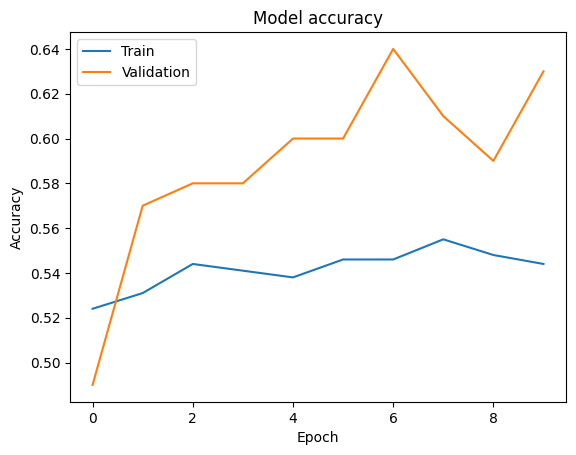

In [18]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import History 
import matplotlib.pyplot as plt
import numpy as np

# Define your MLP model
model = Sequential()
model.add(Dense(64, input_dim=10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define training and validation data
X_train = np.random.rand(1000, 10)
y_train = np.random.randint(0, 2, size=(1000,))
X_val = np.random.rand(100, 10)
y_val = np.random.randint(0, 2, size=(100,))

# Train the model
history = History()
model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), callbacks=[history])

# Plot the accuracy values over epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


**Model Confusion Matrix**

In [19]:
from sklearn.metrics import confusion_matrix

cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[4305,    1,  674,   10],
       [  24,  328,  119,   71],
       [  70,  110, 2189,  814],
       [  49,  192, 1706, 2133]])

<Axes: >

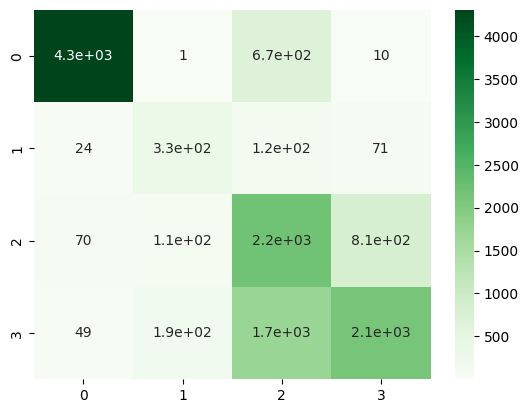

In [20]:
import seaborn as sns

# plot confusion matrix as a heatmap
sns.heatmap(cnf_matrix, annot=True, cmap='Greens')